In [1]:
from astropy.io import fits
import os
import glob
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

# Loading the Data
## prism

In [2]:
# Directory containing your FITS files
fits_pattern = '../data/JADES/DR4/**/clear-prism/**/*_x1d.fits'
fits_files = sorted(glob.glob(fits_pattern, recursive=True))

data_list = []

for file in tqdm(fits_files, desc="Processing FITS files"):
    with fits.open(file) as hdul:
        extract1d_hdu = None
        for hdu in hdul:
            extname = hdu.header.get('EXTNAME', '').strip().upper()
            if extname in ['EXTRACT5PIX1D', 'EXTRACT3PIX1D', 'EXTRACTOPT1D', 'EXTRACT1D']:
                extract1d_hdu = hdu
                break

        if extract1d_hdu is None or not hasattr(extract1d_hdu, 'columns'):
            continue

        table_data = extract1d_hdu.data
        required_columns = ['WAVELENGTH', 'FLUX', 'FLUX_ERR']
        if not all(col in [c.upper() for c in extract1d_hdu.columns.names] for col in required_columns):
            continue

        wavelength = np.array(table_data['WAVELENGTH'], dtype=np.float64)
        flux = np.array(table_data['FLUX'], dtype=np.float64)
        flux_err = np.array(table_data['FLUX_ERR'], dtype=np.float64)

        # Extract RA, DEC, and FIELD from PRIMARY HEADER (HDU 0)
        primary_header = hdul[0].header
        ra_values = np.full_like(wavelength, primary_header.get('RA', np.nan))
        dec_values = np.full_like(wavelength, primary_header.get('DEC', np.nan))

        # Compute average RA and DEC
        avg_ra = np.array(np.nanmean(ra_values), dtype=np.float64)  # Convert to NumPy float
        avg_dec = np.array(np.nanmean(dec_values), dtype=np.float64)

        field = primary_header.get('HLSPTARG', 'UNKNOWN')  # Extract field name

        data_list.append({
            'file_name': os.path.basename(file),
            'FIELD': field,
            'WAVELENGTH': wavelength,
            'FLUX': flux,
            'FLUX_ERR': flux_err,
            'RA': avg_ra,  # Now a single NumPy float
            'DEC': avg_dec  # Now a single NumPy float
        })

df_prism = pd.DataFrame(data_list)

# Ensure all numerical columns are NumPy arrays
numerical_columns = ['WAVELENGTH', 'FLUX', 'FLUX_ERR', 'RA', 'DEC']
for col in numerical_columns:
    df_prism[col] = df_prism[col].apply(lambda x: np.array(x, dtype=np.float64))

Processing FITS files: 100%|██████████| 6020/6020 [00:09<00:00, 659.93it/s]


## g140m

In [3]:
# Directory containing your FITS files
fits_pattern = '../data/JADES/DR4/**/f070lp-g140m/**/*_x1d.fits'
fits_files = sorted(glob.glob(fits_pattern, recursive=True))

data_list = []

for file in tqdm(fits_files, desc="Processing G140M FITS files"):
    with fits.open(file) as hdul:
        extract1d_hdu = None
        for hdu in hdul:
            extname = hdu.header.get('EXTNAME', '').strip().upper()
            if extname in ['EXTRACT5PIX1D', 'EXTRACT3PIX1D', 'EXTRACTOPT1D', 'EXTRACT1D']:
                extract1d_hdu = hdu
                break

        if extract1d_hdu is None or not hasattr(extract1d_hdu, 'columns'):
            continue

        table_data = extract1d_hdu.data
        required_columns = ['WAVELENGTH', 'FLUX', 'FLUX_ERR']
        if not all(col in [c.upper() for c in extract1d_hdu.columns.names] for col in required_columns):
            continue

        wavelength = np.array(table_data['WAVELENGTH'], dtype=np.float64)
        flux = np.array(table_data['FLUX'], dtype=np.float64)
        flux_err = np.array(table_data['FLUX_ERR'], dtype=np.float64)

        primary_header = hdul[0].header
        ra_values = np.full_like(wavelength, primary_header.get('RA', np.nan))
        dec_values = np.full_like(wavelength, primary_header.get('DEC', np.nan))

        avg_ra = np.array(np.nanmean(ra_values), dtype=np.float64)
        avg_dec = np.array(np.nanmean(dec_values), dtype=np.float64)

        field = primary_header.get('HLSPTARG', 'UNKNOWN')

        data_list.append({
            'file_name': os.path.basename(file),
            'FIELD': field,
            'WAVELENGTH': wavelength,
            'FLUX': flux,
            'FLUX_ERR': flux_err,
            'RA': avg_ra,
            'DEC': avg_dec
        })

df_g140m = pd.DataFrame(data_list)

numerical_columns = ['WAVELENGTH', 'FLUX', 'FLUX_ERR', 'RA', 'DEC']
for col in numerical_columns:
    df_g140m[col] = df_g140m[col].apply(lambda x: np.array(x, dtype=np.float64))

Processing G140M FITS files: 100%|██████████| 4728/4728 [00:07<00:00, 632.90it/s]


## g235m

In [4]:
# Directory containing your FITS files
fits_pattern = '../data/JADES/DR4/**/f170lp-g235m/**/*_x1d.fits'
fits_files = sorted(glob.glob(fits_pattern, recursive=True))

data_list = []

for file in tqdm(fits_files, desc="Processing G235M FITS files"):
    with fits.open(file) as hdul:
        extract1d_hdu = None
        for hdu in hdul:
            extname = hdu.header.get('EXTNAME', '').strip().upper()
            if extname in ['EXTRACT5PIX1D', 'EXTRACT3PIX1D', 'EXTRACTOPT1D', 'EXTRACT1D']:
                extract1d_hdu = hdu
                break

        if extract1d_hdu is None or not hasattr(extract1d_hdu, 'columns'):
            continue

        table_data = extract1d_hdu.data
        required_columns = ['WAVELENGTH', 'FLUX', 'FLUX_ERR']
        if not all(col in [c.upper() for c in extract1d_hdu.columns.names] for col in required_columns):
            continue

        wavelength = np.array(table_data['WAVELENGTH'], dtype=np.float64)
        flux = np.array(table_data['FLUX'], dtype=np.float64)
        flux_err = np.array(table_data['FLUX_ERR'], dtype=np.float64)

        primary_header = hdul[0].header
        ra_values = np.full_like(wavelength, primary_header.get('RA', np.nan))
        dec_values = np.full_like(wavelength, primary_header.get('DEC', np.nan))

        avg_ra = np.array(np.nanmean(ra_values), dtype=np.float64)
        avg_dec = np.array(np.nanmean(dec_values), dtype=np.float64)

        field = primary_header.get('HLSPTARG', 'UNKNOWN')

        data_list.append({
            'file_name': os.path.basename(file),
            'FIELD': field,
            'WAVELENGTH': wavelength,
            'FLUX': flux,
            'FLUX_ERR': flux_err,
            'RA': avg_ra,
            'DEC': avg_dec
        })

df_g235m = pd.DataFrame(data_list)

numerical_columns = ['WAVELENGTH', 'FLUX', 'FLUX_ERR', 'RA', 'DEC']
for col in numerical_columns:
    df_g235m[col] = df_g235m[col].apply(lambda x: np.array(x, dtype=np.float64))

Processing G235M FITS files: 100%|██████████| 4539/4539 [00:07<00:00, 630.69it/s]


## g395m

In [5]:
# Directory containing your FITS files
fits_pattern = '../data/JADES/DR4/**/f290lp-g395m/**/*_x1d.fits'
fits_files = sorted(glob.glob(fits_pattern, recursive=True))

data_list = []

for file in tqdm(fits_files, desc="Processing G395M FITS files"):
    with fits.open(file) as hdul:
        extract1d_hdu = None
        for hdu in hdul:
            extname = hdu.header.get('EXTNAME', '').strip().upper()
            if extname in ['EXTRACT5PIX1D', 'EXTRACT3PIX1D', 'EXTRACTOPT1D', 'EXTRACT1D']:
                extract1d_hdu = hdu
                break

        if extract1d_hdu is None or not hasattr(extract1d_hdu, 'columns'):
            continue

        table_data = extract1d_hdu.data
        required_columns = ['WAVELENGTH', 'FLUX', 'FLUX_ERR']
        if not all(col in [c.upper() for c in extract1d_hdu.columns.names] for col in required_columns):
            continue

        wavelength = np.array(table_data['WAVELENGTH'], dtype=np.float64)
        flux = np.array(table_data['FLUX'], dtype=np.float64)
        flux_err = np.array(table_data['FLUX_ERR'], dtype=np.float64)

        primary_header = hdul[0].header
        ra_values = np.full_like(wavelength, primary_header.get('RA', np.nan))
        dec_values = np.full_like(wavelength, primary_header.get('DEC', np.nan))

        avg_ra = np.array(np.nanmean(ra_values), dtype=np.float64)
        avg_dec = np.array(np.nanmean(dec_values), dtype=np.float64)

        field = primary_header.get('HLSPTARG', 'UNKNOWN')

        data_list.append({
            'file_name': os.path.basename(file),
            'FIELD': field,
            'WAVELENGTH': wavelength,
            'FLUX': flux,
            'FLUX_ERR': flux_err,
            'RA': avg_ra,
            'DEC': avg_dec
        })

df_g395m = pd.DataFrame(data_list)

numerical_columns = ['WAVELENGTH', 'FLUX', 'FLUX_ERR', 'RA', 'DEC']
for col in numerical_columns:
    df_g395m[col] = df_g395m[col].apply(lambda x: np.array(x, dtype=np.float64))

Processing G395M FITS files: 100%|██████████| 4728/4728 [00:07<00:00, 642.83it/s]


# Match all four dataframes together

In [6]:
def match_spectra(df_list, match_radius=0.1):
    """
    Matches multiple spectral dataframes based on FIELD, and then RA/DEC (within match_radius in arcseconds).
    The matching is done by taking the first catalogue as a fixed reference.
    For each object in the reference catalogue:
      1. Check that all other catalogues contain at least one row with the same FIELD.
      2. For those candidate rows with the same FIELD, pick the one with the smallest angular separation.
         If that separation is below match_radius, the match is accepted.
    Only reference objects that have valid matches in all catalogues are kept.
    
    Parameters:
      df_list (list of pd.DataFrame): List of dataframes to match.
      match_radius (float): Matching radius in arcseconds.
    
    Returns:
      pd.DataFrame: A matched dataframe containing common sources with unique column names.
    """
    ref_df = df_list[0]
    n_ref = len(ref_df)
    
    # Prepare a list of lists to store the indices of the matched rows.
    # For the reference, it is just the row index.
    matched_indices = [ [] for _ in df_list ]
    
    # Loop over each row in the reference dataframe.
    for j in range(n_ref):
        field_val = ref_df.at[j, "FIELD"]
        ra_ref = ref_df.at[j, "RA"]
        dec_ref = ref_df.at[j, "DEC"]
        ref_coord = SkyCoord(ra=ra_ref * u.deg, dec=dec_ref * u.deg)
        
        # Store the match for the first catalogue (i.e. the reference itself)
        current_match = [j]
        valid_match = True
        
        # Loop over each of the other dataframes.
        for i in range(1, len(df_list)):
            cat_df = df_list[i]
            # First, select only rows that have the same FIELD.
            candidates = cat_df[cat_df["FIELD"] == field_val]
            if candidates.empty:
                valid_match = False
                break
            
            # Now, create SkyCoord objects for these candidates.
            cat_coords = SkyCoord(ra=candidates["RA"].values * u.deg,
                                   dec=candidates["DEC"].values * u.deg)
            # Compute separations from the reference coordinate.
            separations = ref_coord.separation(cat_coords)
            min_sep = separations.min()
            # Check if the smallest separation is within the match radius.
            if min_sep.arcsec < match_radius:
                # Get the candidate index in the original dataframe.
                candidate_idx = candidates.index[separations.argmin()]
                current_match.append(candidate_idx)
            else:
                valid_match = False
                break
        
        # Only if we have a valid match across all catalogues, record it.
        if valid_match and len(current_match) == len(df_list):
            for i in range(len(df_list)):
                matched_indices[i].append(current_match[i])
    
    # If no valid matches, return an empty DataFrame.
    if not matched_indices[0]:
        return pd.DataFrame()
    
    # Build the matched DataFrames.
    matched_dfs = []
    for i, df in enumerate(df_list):
        df_matched = df.loc[matched_indices[i]].reset_index(drop=True)
        df_matched = df_matched.add_suffix(f'_{i+1}')
        matched_dfs.append(df_matched)
    
    # Concatenate along columns.
    matched_df = pd.concat(matched_dfs, axis=1, join="inner")
    return matched_df

In [7]:
#matching the spectra
matched_df = match_spectra([df_prism, df_g140m, df_g235m, df_g395m], match_radius=0.01)

# Combine the high resolution data

In [8]:
def combine_and_bin_high_res_spectra(matched_df, grid_resolution=0.0001, sigma_smooth=1):
    """
    Combines three batches of high-resolution spectra by binning onto an artificial grid,
    interpolates low-res data onto this grid, and smooths high-res flux + error.

    Also prints native and binned resolution R at λ = 2.0 µm for each row.
    """
    import numpy as np
    import pandas as pd
    from scipy.ndimage import gaussian_filter1d
    from scipy import interpolate as interp
    from scipy.stats import binned_statistic

    def fill_nans_with_interp(x, y):
        valid = ~np.isnan(y)
        if np.sum(valid) < 2:
            if np.sum(valid) == 1:
                y = np.full_like(y, y[valid][0])
            return y
        y_filled = np.copy(y)
        y_filled[~valid] = np.interp(x[~valid], x[valid], y[valid])
        return y_filled

    new_data = []

    for index, row in matched_df.iterrows():
        wavelength_low = np.array(row['WAVELENGTH_1'], dtype=float)
        flux_low = np.array(row['FLUX_1'], dtype=float)
        flux_err_low = np.array(row['FLUX_ERR_1'], dtype=float)

        # Combine high-res spectra from batches 2, 3, and 4
        high_res_wavelengths = []
        high_res_fluxes = []
        high_res_flux_errs = []

        for i in range(2, 5):  # now includes batch 4
            wl_key = f'WAVELENGTH_{i}'
            flux_key = f'FLUX_{i}'
            err_key = f'FLUX_ERR_{i}'
            if wl_key in matched_df.columns and flux_key in matched_df.columns and err_key in matched_df.columns:
                wl_arr = np.array(row[wl_key], dtype=float)
                flux_arr = np.array(row[flux_key], dtype=float)
                err_arr = np.array(row[err_key], dtype=float)
                valid = ~np.isnan(wl_arr) & ~np.isnan(flux_arr) & ~np.isnan(err_arr)
                if np.any(valid):
                    high_res_wavelengths.append(wl_arr[valid])
                    high_res_fluxes.append(flux_arr[valid])
                    high_res_flux_errs.append(err_arr[valid])

        if len(high_res_wavelengths) == 0:
            continue

        combined_wavelength = np.concatenate(high_res_wavelengths)
        combined_flux = np.concatenate(high_res_fluxes)
        combined_flux_err = np.concatenate(high_res_flux_errs)

        sort_idx = np.argsort(combined_wavelength)
        combined_wavelength = combined_wavelength[sort_idx]
        combined_flux = combined_flux[sort_idx]
        combined_flux_err = combined_flux_err[sort_idx]

        # Define bin grid
        min_wl = np.min(combined_wavelength)
        max_wl = np.max(combined_wavelength)
        bins = np.arange(min_wl, max_wl + grid_resolution, grid_resolution)
        bin_centers = 0.5 * (bins[1:] + bins[:-1])

        # Compute resolution at λ = 2.0 µm
        lambda_target = 2.0  # microns

        # Native R
        delta_lambda_native = np.diff(combined_wavelength)
        midpoints_native = 0.5 * (combined_wavelength[1:] + combined_wavelength[:-1])
        idx_native = np.argmin(np.abs(midpoints_native - lambda_target))
        if 0 <= idx_native < len(delta_lambda_native):
            dl_native = delta_lambda_native[idx_native]
            R_native = lambda_target / dl_native
        else:
            R_native = np.nan

        # Binned R
        idx_binned = np.argmin(np.abs(bin_centers - lambda_target))
        if 0 < idx_binned < len(bin_centers):
            dl_binned = bin_centers[idx_binned] - bin_centers[idx_binned - 1]
            R_binned = lambda_target / dl_binned
        else:
            R_binned = np.nan

        print(f"[{index}] Native R ≈ {R_native:.1f}, Binned R ≈ {R_binned:.1f} at λ = 2.0000 µm")

        # Bin high-res data
        binned_flux, _, _ = binned_statistic(combined_wavelength, combined_flux, statistic='mean', bins=bins)
        binned_flux_err, _, _ = binned_statistic(combined_wavelength, combined_flux_err, statistic='mean', bins=bins)

        binned_flux = fill_nans_with_interp(bin_centers, binned_flux)
        binned_flux_err = fill_nans_with_interp(bin_centers, binned_flux_err)

        # Define overlap region
        final_min = max(np.min(wavelength_low), bin_centers[0])
        final_max = min(np.max(wavelength_low), bin_centers[-1])
        mask = (bin_centers >= final_min) & (bin_centers <= final_max)

        bin_centers_final = bin_centers[mask]
        binned_flux_final = binned_flux[mask]
        binned_flux_err_final = binned_flux_err[mask]

        # Interpolate low-res data onto bin grid
        low_flux_interp = interp.interp1d(
            wavelength_low, flux_low, kind='linear',
            bounds_error=False, fill_value="extrapolate"
        )(bin_centers_final)
        low_flux_interp = fill_nans_with_interp(bin_centers_final, low_flux_interp)

        low_err_interp = interp.interp1d(
            wavelength_low, flux_err_low, kind='linear',
            bounds_error=False, fill_value="extrapolate"
        )(bin_centers_final)
        low_err_interp = fill_nans_with_interp(bin_centers_final, low_err_interp)

        wl_low_interp = interp.interp1d(
            wavelength_low, wavelength_low, kind='linear',
            bounds_error=False, fill_value="extrapolate"
        )(bin_centers_final)
        wl_low_interp = fill_nans_with_interp(bin_centers_final, wl_low_interp)

        # Smooth high-res data
        if sigma_smooth > 0:
            flux_high_smoothed = gaussian_filter1d(binned_flux_final, sigma=sigma_smooth)
            flux_high_smoothed = fill_nans_with_interp(bin_centers_final, flux_high_smoothed)

            flux_high_smoothed_err = gaussian_filter1d(binned_flux_err_final, sigma=sigma_smooth)
            flux_high_smoothed_err = fill_nans_with_interp(bin_centers_final, flux_high_smoothed_err)
        else:
            flux_high_smoothed = binned_flux_final.copy()
            flux_high_smoothed_err = binned_flux_err_final.copy()

        new_row = {
            'id': index,
            'ra': row['RA_1'],
            'dec': row['DEC_1'],
            'field': row['FIELD_1'],
            'wavelength_high': bin_centers_final,
            'flux_high': binned_flux_final,
            'flux_high_err': binned_flux_err_final,
            'flux_high_smoothed': flux_high_smoothed,
            'flux_high_smoothed_err': flux_high_smoothed_err,
            'wavelength_low': wl_low_interp,
            'flux_low': low_flux_interp,
            'flux_low_err': low_err_interp,
            'filename1': row.get('file_name_1', None),
            'filename2': row.get('file_name_2', None),
            'filename3': row.get('file_name_3', None),
            'filename4': row.get('file_name_4', None),
        }
        new_data.append(new_row)

    return pd.DataFrame(new_data)

In [9]:
combined_df = combine_and_bin_high_res_spectra(matched_df,  grid_resolution=0.001, sigma_smooth=0)

[0] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[1] Native R ≈ 1872.3, Binned R ≈ 2000.0 at λ = 2.0000 µm
[2] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[3] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[4] Native R ≈ 1872.3, Binned R ≈ 2000.0 at λ = 2.0000 µm
[5] Native R ≈ 1872.3, Binned R ≈ 2000.0 at λ = 2.0000 µm
[6] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[7] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[8] Native R ≈ 1872.3, Binned R ≈ 2000.0 at λ = 2.0000 µm
[9] Native R ≈ 1872.3, Binned R ≈ 2000.0 at λ = 2.0000 µm
[10] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[11] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[12] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[13] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[14] Native R ≈ 1872.3, Binned R ≈ 2000.0 at λ = 2.0000 µm
[15] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[16] Native R ≈ 4873.2, Binned R ≈ 2000.0 at λ = 2.0000 µm
[17] Na

# Extracting the redshifts from the catalogues and applying the quality cut

In [11]:
from astropy.io import fits
from astropy.io.fits.verify import VerifyWarning
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=VerifyWarning)

# === DR4 catalog path ===
catalog_path = "../data/JADES/DR4/Combined_DR4_external_v1.2.1.fits"


def to_native_endian(arr):
    """Convert numpy array to native endianness when needed."""
    arr = np.asarray(arr)
    if arr.dtype.byteorder in ('=', '|'):
        return arr
    # Works with NumPy 2.x without using ndarray.newbyteorder
    return arr.byteswap().view(arr.dtype.newbyteorder('='))


def fits_table_to_df(hdu, columns):
    """Convert selected FITS table columns to a DataFrame, flattening (N,1) columns."""
    data = hdu.data
    out = {}
    for col in columns:
        if col not in data.names:
            continue
        arr = to_native_endian(data[col])
        if arr.ndim == 1:
            out[col] = arr
        elif arr.ndim == 2 and arr.shape[1] == 1:
            out[col] = to_native_endian(arr[:, 0])
        else:
            # Keep non-1D data as objects to avoid pandas shape errors
            out[col] = [to_native_endian(x) if hasattr(x, 'dtype') else x for x in arr]
    return pd.DataFrame(out)


def normalize_df_endianness(df):
    """Ensure all numeric DataFrame columns are native-endian."""
    for col in df.columns:
        vals = df[col].to_numpy(copy=False)
        if hasattr(vals, 'dtype') and vals.dtype.kind in 'biufc' and vals.dtype.byteorder not in ('=', '|'):
            df[col] = to_native_endian(vals)
    return df


obs_cols = [
    "Unique_ID", "PID", "TIER", "NIRSpec_ID", "NIRCam_DR5_ID", "NIRCam_DR3_ID",
    "RA_TARG", "Dec_TARG", "Field", "z_Spec", "z_PRISM",
]
r1000_cols = [
    "Unique_ID", "PID", "TIER", "NIRSpec_ID", "NIRCam_DR5_ID", "NIRCam_DR3_ID",
    "HBaA_6563_flux", "HBaA_6563_flux_err",
    "O2_3727_flux", "O2_3727_flux_err",
    "O3_5007_flux", "O3_5007_flux_err",
]

with fits.open(catalog_path) as hdul:
    obs_df = fits_table_to_df(hdul["Obs_info"], obs_cols)
    r1000_df = fits_table_to_df(hdul["R1000_5pix"], r1000_cols)

# Decode byte-string columns if needed
for df in (obs_df, r1000_df):
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)

obs_df = normalize_df_endianness(obs_df)
r1000_df = normalize_df_endianness(r1000_df)

# Merge metadata + line fluxes on unique target key
df_redshifts = obs_df.merge(
    r1000_df,
    on=["Unique_ID", "PID", "TIER", "NIRSpec_ID", "NIRCam_DR5_ID", "NIRCam_DR3_ID"],
    how="inner",
)

# Keep only columns needed downstream
columns_keep = [
    "RA_TARG", "Dec_TARG", "Field", "z_Spec", "z_PRISM",
    "HBaA_6563_flux", "HBaA_6563_flux_err",
    "O2_3727_flux", "O2_3727_flux_err",
    "O3_5007_flux", "O3_5007_flux_err",
]
existing_cols = [c for c in columns_keep if c in df_redshifts.columns]
df_redshifts = df_redshifts[existing_cols].copy()

# Use z_Spec if available, otherwise z_PRISM
df_redshifts["z"] = df_redshifts.apply(
    lambda row: row["z_Spec"] if pd.notna(row["z_Spec"]) and row["z_Spec"] != -1 else row["z_PRISM"],
    axis=1,
)

# Require finite redshift
df_redshifts = df_redshifts[df_redshifts["z"].notna()].reset_index(drop=True)
redshift_count = len(df_redshifts)

# S/N threshold
sn_thresh = 5

# Compute S/N for key lines
df_redshifts["HA_SN"] = df_redshifts["HBaA_6563_flux"] / df_redshifts["HBaA_6563_flux_err"]
df_redshifts["OII_SN"] = df_redshifts["O2_3727_flux"] / df_redshifts["O2_3727_flux_err"]
df_redshifts["OIII_SN"] = df_redshifts["O3_5007_flux"] / df_redshifts["O3_5007_flux_err"]

# Keep rows where any line has S/N > threshold
df_redshifts = df_redshifts[
    (df_redshifts["HA_SN"] > sn_thresh)
    | (df_redshifts["OII_SN"] > sn_thresh)
    | (df_redshifts["OIII_SN"] > sn_thresh)
].reset_index(drop=True)

# Drop helper columns
df_redshifts = df_redshifts.drop(columns=["z_Spec", "z_PRISM", "HA_SN", "OII_SN", "OIII_SN"])

# Summary
final_count = len(df_redshifts)
percent_remaining = (final_count / redshift_count) * 100 if redshift_count > 0 else 0
print(f"{final_count} out of {redshift_count} objects remain after S/N > {sn_thresh} cut on Hα, [OII], or [OIII] ({percent_remaining:.2f}%).")


2621 out of 3797 objects remain after S/N > 5 cut on Hα, [OII], or [OIII] (69.03%).


# Adding the redshifts to the combined data frame
and converting the wavelengthes to rest frame wavelength

In [12]:
def match_combined_redshifts(combined_df, df_redshifts, match_tolerance=1.0):
    """
    Matches objects in combined_df with df_redshifts by:
      1) converting full→short field names,
      2) de‐duplicating on (field, ra, dec),
      3) matching each unique object within match_tolerance (arcsec),
      4) merging z back onto all spectrum rows,
      5) computing rest‐frame wavelengths.

    Parameters:
      combined_df (pd.DataFrame): must have ['field','ra','dec',
                                 'wavelength_low','wavelength_high',…]
      df_redshifts (pd.DataFrame): must have ['Field','RA_TARG',
                                            'Dec_TARG','z']
      match_tolerance (float): matching radius in arcsec (default 1.0)

    Returns:
      pd.DataFrame: all cols of combined_df + 'z',
                    'wavelength_low_rest','wavelength_high_rest'
    """
    def get_short_field(f):
        return "GS" if "South" in f else "GN" if "North" in f else f

    df = combined_df.copy()
    df['short_field'] = df['field'].apply(get_short_field)
    df['orig_index']  = df.index

    # 1) Deduplicate unique objects
    uniq = (
        df[['short_field','ra','dec']]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    uniq['z'] = np.nan

    # 2) Match each unique object
    for fld in uniq['short_field'].unique():
        red = df_redshifts[df_redshifts['Field'] == fld]
        if red.empty:
            continue

        sub = uniq[uniq['short_field'] == fld]
        cu  = SkyCoord(ra=sub['ra'].values * u.deg,
                       dec=sub['dec'].values * u.deg)
        cr  = SkyCoord(ra=red['RA_TARG'].values * u.deg,
                       dec=red['Dec_TARG'].values * u.deg)

        idx, d2d, _ = cu.match_to_catalog_sky(cr)
        tol = match_tolerance * u.arcsec
        sel = d2d < tol
        uniq.loc[sub.index[sel], 'z'] = red.iloc[idx[sel]]['z'].values

    # 3) Merge z back & filter
    out = df.merge(
        uniq[['short_field','ra','dec','z']],
        on=['short_field','ra','dec'],
        how='left'
    )
    out = out[out['z'].notna()].copy()

    # 4) Restore order & compute rest‐wavelengths
    out.sort_values('orig_index', inplace=True)
    out['wavelength_low_rest']  = out['wavelength_low']  / (1 + out['z'])
    out['wavelength_high_rest'] = out['wavelength_high'] / (1 + out['z'])

    return out.drop(columns=['short_field','orig_index']) 

In [13]:
combined_df_redshift = match_combined_redshifts(combined_df, df_redshifts, match_tolerance=0.01)

In [14]:
combined_df_redshift.drop(columns=['wavelength_low_rest',
       'wavelength_high_rest'], inplace=True)

In [15]:
combined_df_redshift

,id,ra,dec,field,wavelength_high,flux_high,flux_high_err,flux_high_smoothed,flux_high_smoothed_err,wavelength_low,flux_low,flux_low_err,filename1,filename2,filename3,filename4,z
0,0,189.117202,62.221434,GOODS-North-Medium/HST,"[0.7507727559999999, 0.751772756, 0.7527727559...","[-7.252436303683528e-20, -3.98387049593769e-20...","[1.666557305790514e-19, 1.461592358074945e-19,...","[-7.252436303683528e-20, -3.98387049593769e-20...","[1.666557305790514e-19, 1.461592358074945e-19,...","[0.7507727559999999, 0.751772756, 0.7527727559...","[2.5385485067988796e-20, 2.6596687507557337e-2...","[6.146866955481448e-21, 6.1386010118082945e-21...",hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,4.146842
1,1,189.108075,62.222050,GOODS-North-Medium/HST,"[0.7004999999999999, 0.7015, 0.702499999999999...","[9.557155332946664e-20, 5.943679674654198e-19,...","[8.212688389040855e-19, 7.466082038943362e-19,...","[9.557155332946664e-20, 5.943679674654198e-19,...","[8.212688389040855e-19, 7.466082038943362e-19,...","[0.7004999999999999, 0.7015, 0.702499999999999...","[3.214822116262436e-20, 3.2496529492389704e-20...","[1.1053711451154974e-20, 1.0734069755521752e-2...",hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,3.972548
2,2,189.116947,62.222079,GOODS-North-Medium/HST,"[0.7145000079999999, 0.715500008, 0.7165000079...","[-1.082665410773254e-18, -3.8724815070019355e-...","[4.1693278636631533e-19, 3.317507006639055e-19...","[-1.082665410773254e-18, -3.8724815070019355e-...","[4.1693278636631533e-19, 3.317507006639055e-19...","[0.7145000079999999, 0.715500008, 0.7165000079...","[5.9302362580328166e-21, 5.316200268048604e-21...","[6.53116147222357e-21, 6.5409496435358644e-21,...",hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,5.180958
3,3,189.127411,62.224434,GOODS-North-Medium/HST,"[0.796590964, 0.7975909639999998, 0.798590964,...","[4.4837673475938326e-20, -2.652193032011434e-2...","[7.31979825458488e-20, 6.617289751286978e-20, ...","[4.4837673475938326e-20, -2.652193032011434e-2...","[7.31979825458488e-20, 6.617289751286978e-20, ...","[0.796590964, 0.7975909639999998, 0.798590964,...","[3.854189289206667e-20, 3.845783686427403e-20,...","[6.812670461818058e-21, 6.747831129449629e-21,...",hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,3.976253
4,4,189.110319,62.225442,GOODS-North-Medium/HST,"[0.7004999999999999, 0.7015, 0.702499999999999...","[-3.8838171516320807e-19, -3.7561494574079363e...","[4.2940340117206425e-19, 8.550569218964737e-19...","[-3.8838171516320807e-19, -3.7561494574079363e...","[4.2940340117206425e-19, 8.550569218964737e-19...","[0.7004999999999999, 0.7015, 0.702499999999999...","[-3.1607349335452587e-21, -1.7565047025606195e...","[1.1939113009830458e-20, 1.1897343345851179e-2...",hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,hlsp_jades_jwst_nirspec_goods-n-mediumhst-0000...,5.347199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4442,4442,53.210317,-27.794693,GOODS-South-Medium/JWST,"[0.7011363639999999, 0.702136364, 0.7031363639...","[-1.1205055098523481e-20, 7.076299294717936e-2...","[5.405064126955439e-19, 4.991785851519891e-19,...","[-1.1205055098523481e-20, 7.076299294717936e-2...","[5.405064126955439e-19, 4.991785851519891e-19,...","[0.7011363639999999, 0.702136364, 0.7031363639...","[3.33780178275435

In [16]:
combined_df_redshift.to_pickle("../data/dataset_DR4.pkl") 

# Making the figure for paper

In [17]:
# ---------- helper ----------
def norm_flux(flux, p=99):
    flux = np.asarray(flux, dtype=float)
    finite = flux[np.isfinite(flux)]
    if finite.size == 0:
        return flux
    scale = np.nanpercentile(np.abs(finite), p)
    if scale == 0:
        return flux
    return flux / scale

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Georgia"],     # or Times, if journal prefers
    "font.size": 12,               # base font
    "axes.labelsize": 15,          # x/y axis labels
    "axes.titlesize": 12,
    "legend.fontsize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})
lines = [
    # key,         label,                   λ_rest(μm),   priority, group
    ("LyA",        r"Ly$\alpha$",            0.1216,       1,       "UV"),
    ("NIV_1486",   r"NIV]",                  0.1486,       15,      "UV"),
    ("CIV_1548",   r"CIV",                   0.1548,       10,      "UV"),
    ("CIV_1550",   r"CIV",                   0.1550,       10,      "UV"),
    ("HeII_1640",  r"HeII",                  0.1640,       4,       "UV"),
    ("OIII_1661",  r"OIII]",                 0.1661,       12,      "UV"),
    ("OIII_1666",  r"OIII]",                 0.1666,       12,      "UV"),
    ("CIII_1907",  r"CIII]",                 0.1907,       3,       "UV"),
    ("CIII_1909",  r"CIII]",                 0.1909,       2,       "UV"),
    ("CII_2326",   r"CII]",                  0.2326,       18,      "UV"),
    ("NeIV_2423",  r"NeIV]",                 0.2423,       17,      "UV"),
    ("OII_2471",   r"OII]",                  0.2471,       14,      "UV"),
    ("MgII_2796",  r"MgII",                  0.2796,       8,       "UV"),
    ("MgII_2803",  r"MgII",                  0.2803,       8,       "UV"),

    ("OIII_3133",  r"OIII",                  0.3133,       16,      "blue_optical"),
    ("NeIII_3343", r"[NeIII]",               0.3343,       20,      "blue_optical"),
    ("NeV_3426",   r"[NeV]",                 0.3426,       7,       "blue_optical"),

    ("OII_3726",   r"[OII]",                 0.3726,       6,       "optical"),
    ("OII_3729",   r"[OII]",                 0.3729,       5,       "optical"),
    ("Hdelta",     r"H$\delta$",             0.4102,       13,      "optical"),
    ("Hgamma",     r"H$\gamma$",             0.4340,       11,      "optical"),
    ("OIII_4363",  r"[OIII]",                0.4363,       9,       "optical"),
    ("Hbeta",      r"H$\beta$",              0.4861,       3,       "optical"),
    ("OIII_4959",  r"[OIII]",                0.4959,       4,       "optical"),
    ("OIII_5007",  r"[OIII]",                0.5007,       2,       "optical"),
    ("HeI_5876",   r"HeI",                   0.5876,       14,      "optical"),
    ("Halpha",     r"H$\alpha$",             0.6563,       0,       "optical"),
    ("NII_6548",   r"[NII]",                 0.6548,       8,       "optical"),
    ("NII_6583",   r"[NII]",                 0.6583,       7,       "optical"),
    ("SII_6716",   r"[SII]",                 0.6716,       10,      "optical"),
    ("SII_6731",   r"[SII]",                 0.6731,       9,       "optical"),

    ("SIII_9069",  r"[SIII]",                0.9069,       6,       "NIR"),
    ("SIII_9531",  r"[SIII]",                0.9531,       5,       "NIR"),

    # IR lines (corrected to μm)
    ("FeII_12567", r"FeII",                  1.2567,       19,      "IR"),
    ("PaBeta",     r"Pa$\beta$",             1.2818,       4,       "IR"),
    ("FeII_16435", r"FeII",                  1.6435,       18,      "IR"),
    ("PaAlpha",    r"Pa$\alpha$",            1.8756,       3,       "IR"),
    ("H2_S3",      r"H$_2$ S(3)",            1.9575,       12,      "IR"),
    ("SiVI",       r"[SiVI]",                1.9634,       8,       "IR"),
    ("H2_S1",      r"H$_2$ S(1)",            2.1218,       12,      "IR"),
    ("BrGamma",    r"Br$\gamma$",            2.1660,       10,      "IR"),
    ("BrBeta",     r"Br$\beta$",             2.6250,       11,      "IR"),
    ("BrAlpha",    r"Br$\alpha$",            4.0510,       8,       "IR"),
]

df_lines = pd.DataFrame(lines, columns=["key", "label", "wavelength", "priority", "group"])


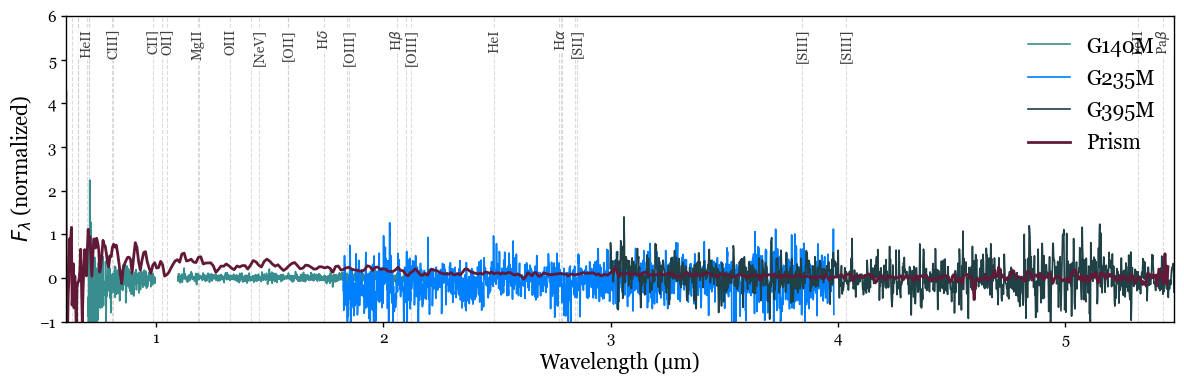

In [18]:

i=120
z=3.235

# ---------- extract spectra ----------
w140 = np.asarray(matched_df["WAVELENGTH_2"][i])
f140 = np.asarray(matched_df["FLUX_2"][i])

w235 = np.asarray(matched_df["WAVELENGTH_3"][i])
f235 = np.asarray(matched_df["FLUX_3"][i])

w395 = np.asarray(matched_df["WAVELENGTH_4"][i])
f395 = np.asarray(matched_df["FLUX_4"][i])

wpr  = np.asarray(matched_df["WAVELENGTH_1"][i])
fpr  = np.asarray(matched_df["FLUX_1"][i])

# ----- plasma-inspired NIRSpec colors -----
# --- Colorblind-friendly APJ-grade palette ---

g140m_color = "#388E8E"   # deep blue
g235m_color = "#007FFF"   # indigo / blue-violet
g395m_color = "#1F4045"   # soft violet

prism_color =   "#601936" # warm contrasting orange

emline_color = "0.80"
label_color  = "0.25"



# ---------- plot spectra ----------
plt.figure(figsize=(12, 4))

plt.plot(w140, norm_flux(f140), label="G140M",
         color=g140m_color, lw=1.2)
plt.plot(w235, norm_flux(f235), label="G235M",
         color=g235m_color, lw=1.2)
plt.plot(w395, norm_flux(f395), label="G395M",
         color=g395m_color, lw=1.2)

plt.plot(wpr,  norm_flux(fpr),  label="Prism",
         color=prism_color, lw=2.0)

plt.xlabel("Wavelength (μm)")
plt.ylabel(r"$F_\lambda$ (normalized)")

plt.legend(frameon=False, loc="upper right")

# your preferred y-range
plt.ylim([-1, 6])
ax = plt.gca()
ymin, ymax = ax.get_ylim()

# x-range from data
all_waves = np.hstack([w140, w235, w395, wpr])
x_min = np.nanmin(all_waves)
x_max = np.nanmax(all_waves)
plt.xlim(x_min, x_max)

# ---------- use df_lines to get observed wavelengths ----------
df_plot = df_lines.copy()
df_plot["obs_wavelength"] = (1.0 + z) * df_plot["wavelength"]

# keep only lines within coverage
mask = (df_plot["obs_wavelength"] >= x_min) & (df_plot["obs_wavelength"] <= x_max)
df_plot = df_plot[mask].sort_values("obs_wavelength")

# ---------- cluster close lines & choose which to label ----------
label_keys = set()

if not df_plot.empty:
    delta = 0.04  # μm; lines closer than this are considered "crowded"

    # turn into list of namedtuples for easier handling
    rows = list(df_plot.itertuples(index=False))

    clusters = []
    current = [rows[0]]
    for row in rows[1:]:
        if abs(row.obs_wavelength - current[-1].obs_wavelength) <= delta:
            current.append(row)
        else:
            clusters.append(current)
            current = [row]
    clusters.append(current)

    # choose one per cluster based on minimum 'priority'
    for cluster in clusters:
        if len(cluster) == 1:
            label_keys.add(cluster[0].key)
        else:
            best = min(cluster, key=lambda r: r.priority)
            label_keys.add(best.key)

# ---------- draw all lines, label cluster reps ----------
y_label = ymax * 0.95

for row in df_plot.itertuples(index=False):
    lam = row.obs_wavelength

    # vertical dashed line (for every line)
    ax.axvline(
        lam,
        color=emline_color,
        linestyle="--",
        linewidth=0.8,
        alpha=0.7,
        zorder=0,
    )

    # only label chosen representatives
    if row.key not in label_keys:
        continue

    ax.text(
        lam,
        y_label,
        row.label,                 # LaTeX string from df_lines
        rotation=90,
        ha="center",
        va="top",
        fontsize=10,
        color=label_color,
        clip_on=False,
        bbox=dict(
            boxstyle="round,pad=0.12",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
    )

plt.tight_layout()
plt.savefig("../plots/matched_spectra_comparison_DR4.png",
        dpi=450,
        bbox_inches="tight",
        pad_inches=0.05)
plt.show()
